# MEPI v1 — xLSTM pretraining

**Purpose:** train the `xLSTM` candidate using the frozen common MagNet protocol.  
**Inputs:** audited MagNet HDF5 plus deterministic train/validation/test manifests.  
**Outputs:** `experiments/pretrain_v1/xLSTM/` checkpoints, metrics, environment, summary, and measured evidence.  
**Frozen protocol:** MEPI-FROZEN-PROTOCOL v1.1.  
**Trains a model:** yes. The test split is opened only after the validation-selected best checkpoint is frozen.  
**Restart behavior:** a compatible rolling checkpoint resumes automatically; a COMPLETE run skips training.

**Saved-output notice:** Existing outputs in this file predate the v1.1 migration and are retained only as historical execution evidence. Run All replaces them with current v1.1 validation output.


In [1]:
from pathlib import Path

# MEPI Run-All configuration. Safe recovery is the default.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src" / "mepi_v1").is_dir():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory")
SEED = 42
FORCE_RETRAIN = False
AUTO_RESUME = True
CHECKPOINT_EVERY_N_STEPS = 1000

print(f"[PASS] Configuration loaded: PROJECT_ROOT={PROJECT_ROOT}, SEED={SEED}")
print(f"FORCE_RETRAIN={FORCE_RETRAIN}; AUTO_RESUME={AUTO_RESUME}; checkpoint interval={CHECKPOINT_EVERY_N_STEPS} steps")


[PASS] Configuration loaded: PROJECT_ROOT=<REPOSITORY_ROOT>, SEED=42
FORCE_RETRAIN=False; AUTO_RESUME=True; checkpoint interval=1000 steps


## Setup

Import the shared source workflow. Notebook cells contain orchestration only.

In [2]:
import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.mepi_v1.notebook_workflow import PretrainingNotebookRun
print("[PASS] Project source imports completed")


[PASS] Project source imports completed


## A — Notebook identity

Confirm the candidate, protocol, output directory, and recovery behavior.

In [3]:
run = PretrainingNotebookRun(PROJECT_ROOT, "xLSTM", seed=SEED, force_retrain=FORCE_RETRAIN, auto_resume=AUTO_RESUME, checkpoint_every_n_steps=CHECKPOINT_EVERY_N_STEPS)
identity = run.print_identity()


MEPI PRETRAIN RERUN v1
Backbone: xLSTM
Protocol: MEPI-FROZEN-PROTOCOL v1.0
Output Directory: <REPOSITORY_ROOT>/experiments/pretrain_v1/xLSTM
Restart Behavior: compatible last_checkpoint.pt auto-resume; completed run skips
Common runtime: batch_size=256, workers=4, AMP=True, TF32=True, deterministic_algorithms=False


## B — Environment

Display Python/PyTorch/CUDA/GPU/project details. This training notebook fails closed without CUDA.

In [4]:
environment_rows = run.check_environment(require_cuda=True)
import pandas as pd
display(pd.DataFrame(environment_rows))


[PASS] Project root: <REPOSITORY_ROOT>
[PASS] Python executable: <USER_HOME>/miniconda3/envs/trans-core/bin/python
[PASS] Python version: 3.11.15 | packaged by conda-forge | (main, Aug 11 2026, 10:26:29) [GCC 14.4.0]
[PASS] PyTorch import: 2.5.1
[PASS] PyTorch CUDA version: 12.1
[PASS] CUDA available: True
[PASS] GPU model: NVIDIA GeForce RTX 3050
[PASS] Python (trans-core) kernel interpreter: display='Python (trans-core)'; kernel=<USER_HOME>/miniconda3/envs/trans-core/bin/python3.11; active=<USER_HOME>/miniconda3/envs/trans-core/bin/python3.11


,check,status,detail
0,Project root,PASS,
1,Python executable,PASS,/miniconda3/envs/trans-core/bin/p...
2,Python version,PASS,"3.11.15 | packaged by conda-forge | (main, Aug..."
3,PyTorch import,PASS,2.5.1
4,PyTorch CUDA version,PASS,12.1
5,CUDA available,PASS,True
6,GPU model,PASS,NVIDIA GeForce RTX 3050
7,Python (trans-core) kernel interpreter,PASS,display='Python (trans-core)'; kernel=/home/di...


## C — Source and frozen protocol

Require the authoritative protocol and fingerprint the clean source tree.

In [5]:
source_state = run.validate_source_protocol()
display(pd.DataFrame([source_state]))


[PASS] Frozen protocol found: <REPOSITORY_ROOT>/docs/MEPI_FROZEN_PROTOCOL_v1.0.md
[PASS] src.mepi_v1 imports: source fingerprint 6047cecf8c20af9f40b791a10f548b46c3d0bde8eb2d94e09eecd44c42d8f5e0
[PASS] All eight candidate configs share one non-architecture setup: 05e4f2864bbbcaf68de732438a869f75bab0273e646166a669686f3694ab67a1
Git SHA: UNAVAILABLE (source-tree fingerprint retained)


,protocol,protocol_sha256,source_tree_fingerprint,git_sha,candidate_common_config_fingerprint
0,/docs/MEPI_FROZEN_PRO...,ef8f1f85c94ddc18645d25f4537a3eed45e8f46c6d900f...,6047cecf8c20af9f40b791a10f548b46c3d0bde8eb2d94...,None,05e4f2864bbbcaf68de732438a869f75bab0273e646166...


## D — Dataset contract

Verify counts, fingerprints, frozen feature shapes, and exclusion of material/CoreID from predictive inputs.

In [6]:
dataset_state = run.validate_dataset()
display(pd.DataFrame([dataset_state]))


[PASS] Dataset loaded: <REPOSITORY_ROOT>/data/raw/source_datasets/Dataset/magnet_pretrain_186k.h5
Total samples: 186757; Train: 149405; Validation: 18676; Test: 18676
[PASS] Waveform shape: [186757, 1024]; tabular shape: [186757, 2]; target shape: [186757]
[PASS] Tabular fields exactly [frequency_hz, temperature_c]
[PASS] Material/CoreID excluded from predictive input
[PASS] One actual train batch: {'waveform': [1, 1, 1024], 'tabular': [1, 2], 'target': [1]}


,dataset_path,total,counts,waveform_shape,tabular_shape,target_shape,dataset_fingerprint,split_fingerprint,actual_batch_shapes
0,/data/raw/source_data...,186757,"{'train': 149405, 'validation': 18676, 'test':...","[186757, 1024]","[186757, 2]",[186757],0aca43184e9bd6cc90eec736a89fe1ea32f45b126527cb...,df48374b38a3ed42628053491d14ae6cfcb13b38673eb4...,"{'waveform': [1, 1, 1024], 'tabular': [1, 2], ..."


## E — Experiment state

Choose NEW, AUTO-RESUME, or COMPLETE/SKIP without prompting.

In [7]:
experiment_state = run.inspect_status()
display(pd.DataFrame([{k: v for k, v in experiment_state.items() if k != 'summary'}]))


STATUS: NEW RUN


,status,action
0,NEW,FROM_SCRATCH


## F — Recovery checkpoint

Validate every experiment identity field before any state is loaded.

In [8]:
checkpoint_rows = run.inspect_checkpoint()
display(pd.DataFrame(checkpoint_rows))


[PASS] No recovery checkpoint: a new run will initialize from scratch


""


## G — Model and real-batch smoke check

Construct the candidate and run one actual sample through the frozen input contract.

In [9]:
model_state = run.construct_model_smoke()
display(pd.DataFrame([model_state]))


{
  "model": "xLSTM",
  "parameter_count": 3336202,
  "waveform_input_shape": [
    1,
    1,
    1024
  ],
  "tabular_input_shape": [
    1,
    2
  ],
  "target_shape": [
    1
  ],
  "output_shape": [
    1
  ],
  "temporary_heads": 10
}
Material ID used as predictive input: NO
Material metadata routes only the temporary regression head: YES
PIRL instantiated: NO
MTPH instantiated: NO


,model,parameter_count,waveform_input_shape,tabular_input_shape,target_shape,output_shape,temporary_heads
0,xLSTM,3336202,"[1, 1, 1024]","[1, 2]",[1],[1],10


## H — Train or resume

Run the shared recoverable loop. Rolling writes are atomic and only `last_checkpoint.pt` plus `best_checkpoint.pt` may coexist.

In [10]:
training_state = run.train_or_resume()
display(pd.DataFrame([training_state]))


STATUS: NEW RUN
TRAINING MODE: FROM SCRATCH
Epoch 1/20 complete | validation MAE_norm 0.135928 | validation RMSE 0.193154
Epoch 2/20 | step 1000 | train loss 0.055189 | lr 3e-05 | elapsed 662.5s | GPU memory 2.49 GiB
Epoch 2/20 complete | validation MAE_norm 0.078726 | validation RMSE 0.112391
Epoch 3/20 complete | validation MAE_norm 0.059431 | validation RMSE 0.083405
Epoch 4/20 | step 2000 | train loss 0.024190 | lr 3e-05 | elapsed 1425.8s | GPU memory 2.49 GiB
Epoch 4/20 complete | validation MAE_norm 0.048503 | validation RMSE 0.070330
Epoch 5/20 complete | validation MAE_norm 0.039503 | validation RMSE 0.056327
Epoch 6/20 | step 3000 | train loss 0.017351 | lr 3e-05 | elapsed 2220.8s | GPU memory 2.49 GiB
Epoch 6/20 complete | validation MAE_norm 0.043027 | validation RMSE 0.059755
Epoch 7/20 | step 4000 | train loss 0.014233 | lr 3e-05 | elapsed 2974.0s | GPU memory 2.49 GiB
Epoch 7/20 complete | validation MAE_norm 0.044402 | validation RMSE 0.062243
Epoch 8/20 complete | valid

,status,best_epoch,best_step,global_step,start_timestamp,elapsed_seconds,resume_events
0,TRAINING_COMPLETE_EVALUATION_PENDING,20,11680,11680,2026-09-19T15:41:17.248912+00:00,8452.492732,0


## I — Training curves

Render three separate matplotlib figures without seaborn, subplots, or manually assigned colors.

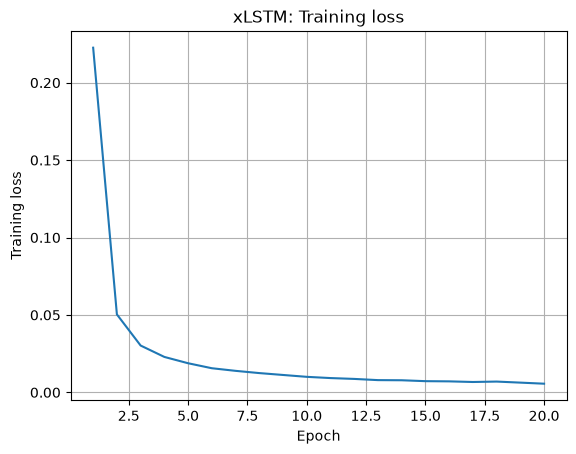

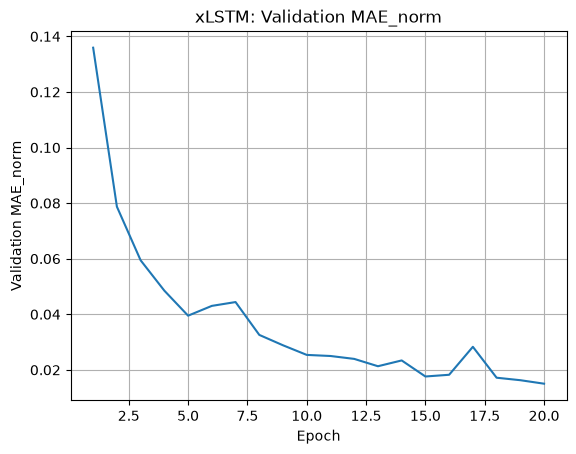

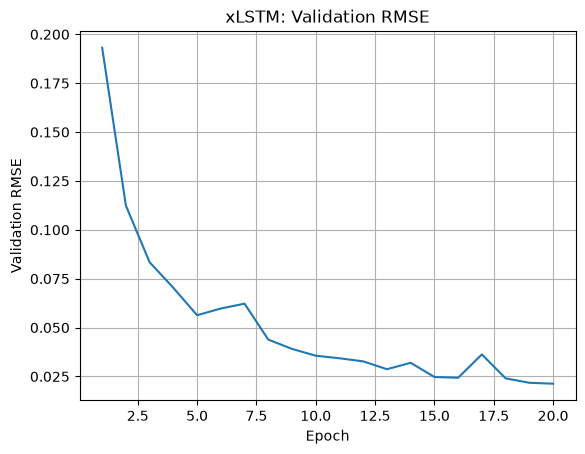

[PASS] Rendered three separate matplotlib training curves
[PASS] Curve figures available: 3


In [11]:
figures = run.plot_curves()
print(f"[PASS] Curve figures available: {len(figures)}")


## J — Frozen best-checkpoint evaluation

Reload the validation-selected best checkpoint, report validation metrics, then access test exactly once.

In [12]:
final_summary = run.evaluate_best_checkpoint()
display(pd.DataFrame([{'split': 'validation', **final_summary['validation_metrics']}, {'split': 'test', **final_summary['test_metrics']}]))


[PASS] Frozen best checkpoint evaluated on validation
[PASS] Test evaluated exactly once after validation selection; test did not alter selection
Validation metrics: {'normalized_mae': 0.015028174539595075, 'rmse': 0.02130570681111045, 'r2': 0.9995541768906988}
Test metrics: {'normalized_mae': 0.015225772670197766, 'rmse': 0.02198038279823661, 'r2': 0.99952488393039}


,split,normalized_mae,rmse,r2
0,validation,0.015028,0.021306,0.999554
1,test,0.015226,0.021980,0.999525


## K — Measured experiment evidence

Write COMPLETE JSON/Markdown evidence only after training and final evaluation succeeded.

In [13]:
evidence = run.write_run_evidence()
print(f"[PASS] Evidence status: {evidence['status']}")


[PASS] COMPLETE measured evidence written: <REPOSITORY_ROOT>/experiments/pretrain_v1/xLSTM/run_evidence.json
[PASS] Evidence status: COMPLETE


## Final notebook summary

This screenshot-friendly cell is intentionally last. Save the executed notebook to preserve visible evidence.

In [14]:
final_evidence = run.display_final_summary()
display(pd.DataFrame([{'backbone': final_evidence['backbone'], 'status': final_evidence['status'], 'best_epoch': final_evidence['best_epoch'], 'validation_mae_norm': final_evidence['validation_metrics']['normalized_mae'], 'test_mae_norm': final_evidence['test_metrics']['normalized_mae'], 'checkpoint_sha256': final_evidence['best_checkpoint_sha256']}]))


MEPI PRETRAINING RUN COMPLETE
Protocol          : MEPI-FROZEN-PROTOCOL v1.0
Backbone          : xLSTM
Training status   : COMPLETE
Resumed           : NO (0 recovery event(s))
Train samples     : 149405
Validation samples: 18676
Test samples      : 18676
Best epoch        : 20
Best step         : 11680
Validation
  MAE_norm        : 0.015028174539595075
  RMSE            : 0.02130570681111045
  R²              : 0.9995541768906988
Test
  MAE_norm        : 0.015225772670197766
  RMSE            : 0.02198038279823661
  R²              : 0.99952488393039
Parameters        : 3336202
Runtime           : 8475.347089758005 seconds
Best checkpoint:
<REPOSITORY_ROOT>/experiments/pretrain_v1/xLSTM/best_checkpoint.pt

Checkpoint SHA256:
6ad61ea11ec661e0633cc0e23dfdb52f5904b5fb2a6287d92198105668e0a090

Evidence:
<REPOSITORY_ROOT>/experiments/pretrain_v1/xLSTM/run_evidence.md

RESULT: SUCCESS
Execution complete.
Please save this notebook to preserve visible outputs as experiment evidence.


,backbone,status,best_epoch,validation_mae_norm,test_mae_norm,checkpoint_sha256
0,xLSTM,COMPLETE,20,0.015028,0.015226,6ad61ea11ec661e0633cc0e23dfdb52f5904b5fb2a6287...
